In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [18]:
df=pd.read_csv("Food_Delivery_Times.csv")

In [19]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [20]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [21]:
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=df[col].fillna(df[col].mode()[0])

In [22]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                    0
Traffic_Level              0
Time_of_Day                0
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

<Axes: ylabel='Courier_Experience_yrs'>

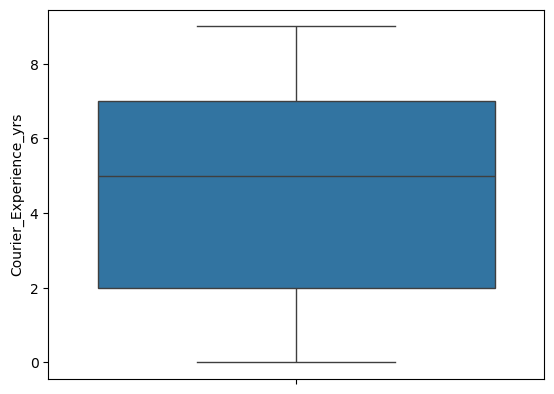

In [23]:
sns.boxplot(df['Courier_Experience_yrs'])

In [24]:
df['Courier_Experience_yrs']=df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean())

In [25]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [26]:
df.drop('Order_ID',inplace=True,axis=1)

In [27]:
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


Correlation with Delivery_Time_min:


Delivery_Time_min         1.000000
Distance_km               0.780998
Preparation_Time_min      0.307350
Courier_Experience_yrs   -0.089066
Name: Delivery_Time_min, dtype: float64

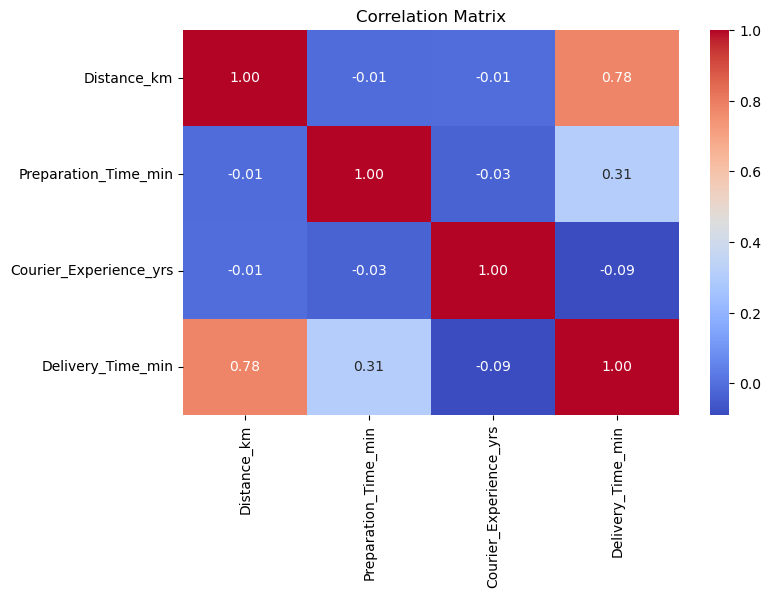

In [28]:
target='Delivery_Time_min'
# Numerical correlations with the target
numeric_cols = df.select_dtypes(include=np.number).columns
correlation = df[numeric_cols].corr()[target].sort_values(ascending=False)

print("Correlation with Delivery_Time_min:")
display(correlation)

plt.figure(figsize=(8, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


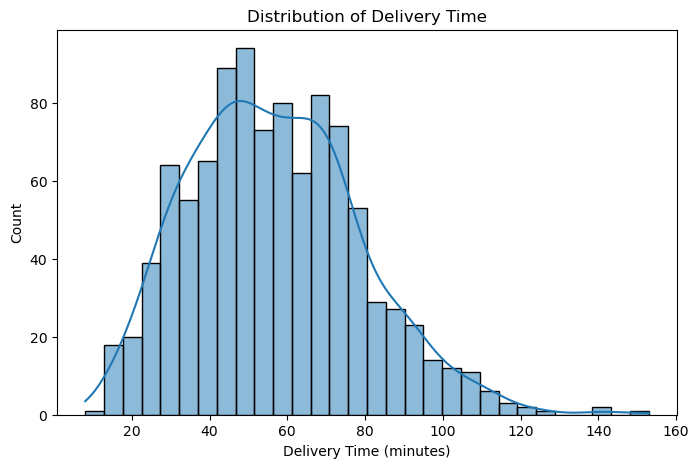

In [29]:
# Distribution of the target
plt.figure(figsize=(8, 5))
sns.histplot(df[target], kde=True, bins=30)
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.show()


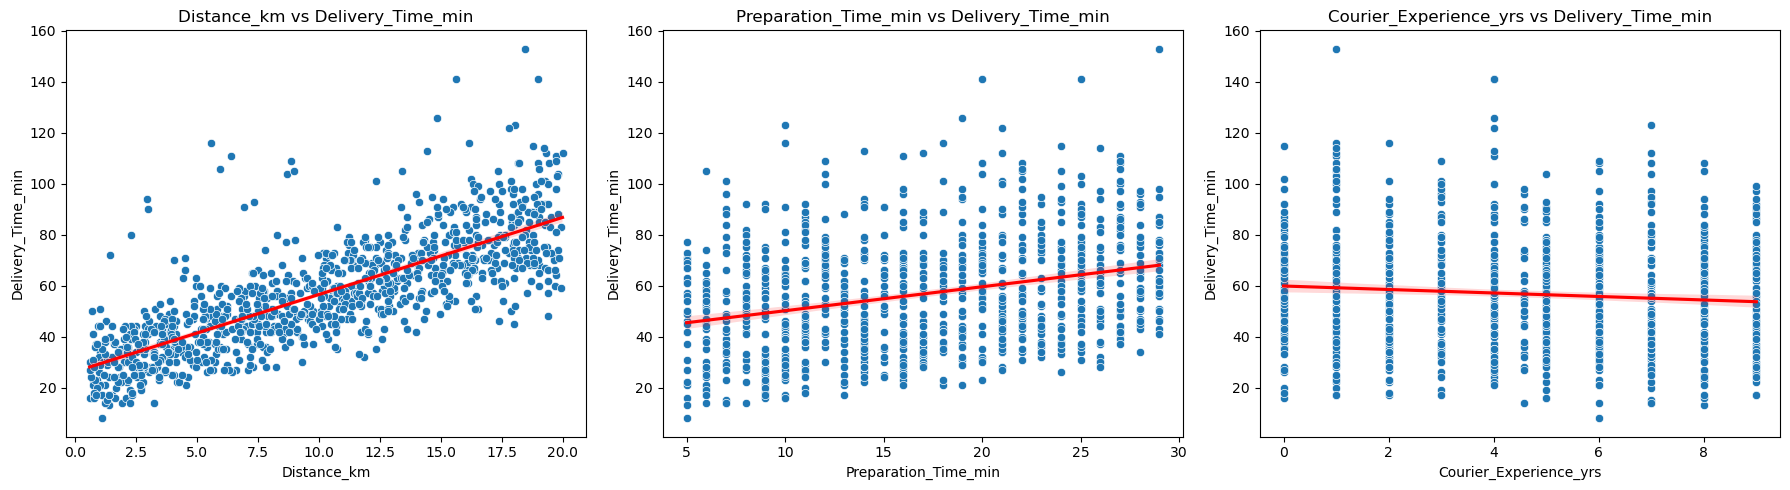

In [30]:
# Numerical features versus target
numerical_features = [
    col for col in numeric_cols
    if col != target
]

fig, axes = plt.subplots(1, len(numerical_features), figsize=(18, 5))

for ax, feature in zip(axes, numerical_features):
    sns.scatterplot(data=df, x=feature, y=target, ax=ax)
    sns.regplot(
        data=df, x=feature, y=target,
        scatter=False, color='red', ax=ax
    )
    ax.set_title(f'{feature} vs {target}')

plt.tight_layout()
plt.show()


Average delivery time by Weather:


,count,mean,median,min,max
Weather,,,,,
Snowy,97,67.113402,66.0,24,115
Rainy,204,59.794118,57.5,15,141
Foggy,103,59.466019,59.0,25,116
Windy,96,55.458333,55.0,16,122
Clear,500,53.150000,52.0,8,153


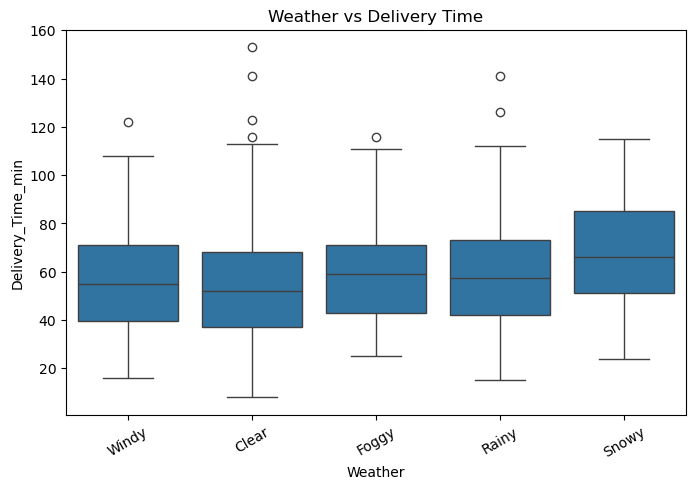


Average delivery time by Traffic_Level:


,count,mean,median,min,max
Traffic_Level,,,,,
High,197,64.807107,65.0,21,122
Medium,420,56.452381,54.0,13,153
Low,383,52.885117,51.0,8,141


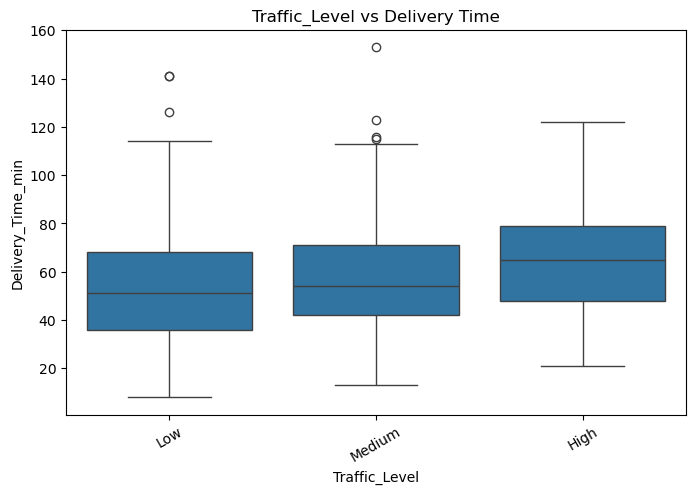


Average delivery time by Time_of_Day:


,count,mean,median,min,max
Time_of_Day,,,,,
Evening,293,57.481229,56.0,13,141
Morning,338,57.011834,56.5,8,153
Afternoon,284,56.080986,56.0,16,109
Night,85,55.211765,52.0,23,108


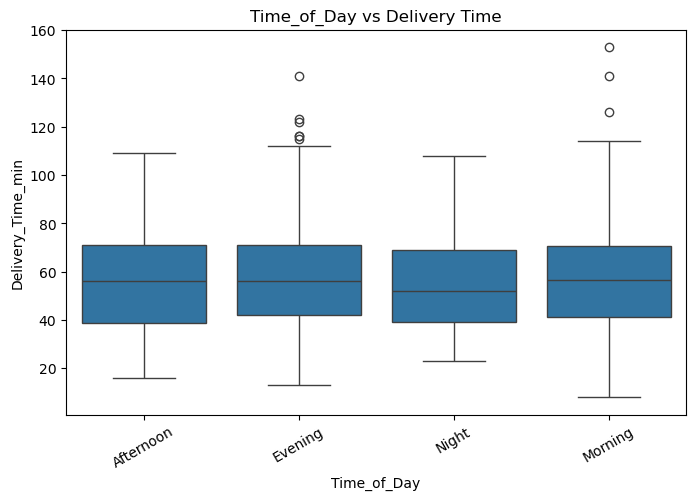


Average delivery time by Vehicle_Type:


,count,mean,median,min,max
Vehicle_Type,,,,,
Car,195,58.200000,56.0,17,141
Bike,503,56.574553,56.0,8,141
Scooter,302,56.046358,54.5,13,153


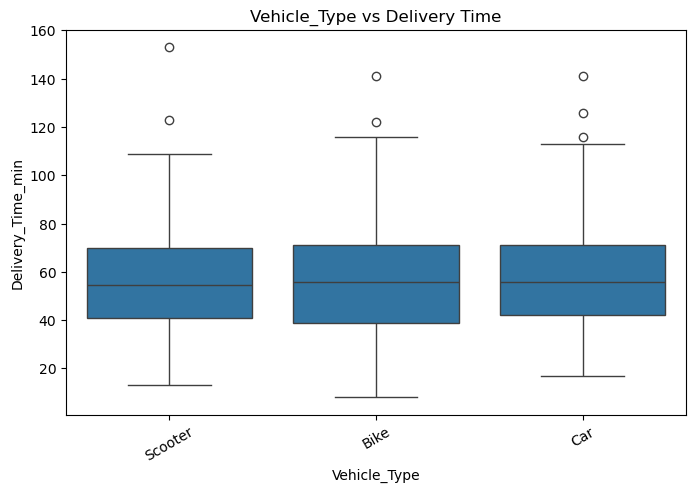

In [31]:
# Categorical features versus target
categorical_features = df.select_dtypes(include='object').columns

for feature in categorical_features:
    print(f"\nAverage delivery time by {feature}:")
    display(
        df.groupby(feature)[target]
          .agg(['count', 'mean', 'median', 'min', 'max'])
          .sort_values('mean', ascending=False)
    )

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=feature, y=target)
    plt.title(f'{feature} vs Delivery Time')
    plt.xticks(rotation=30)
    plt.show()


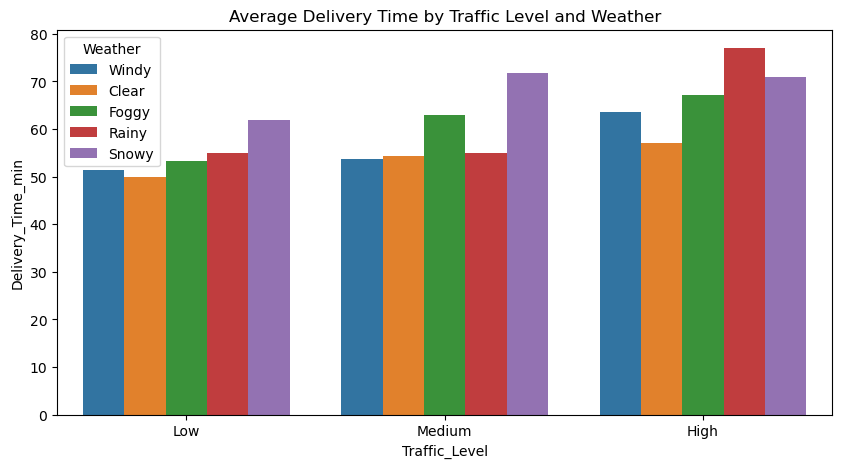

In [32]:
# Mean delivery time by traffic and weather
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x='Traffic_Level',
    y=target,
    hue='Weather',
    errorbar=None
)
plt.title('Average Delivery Time by Traffic Level and Weather')
plt.show()

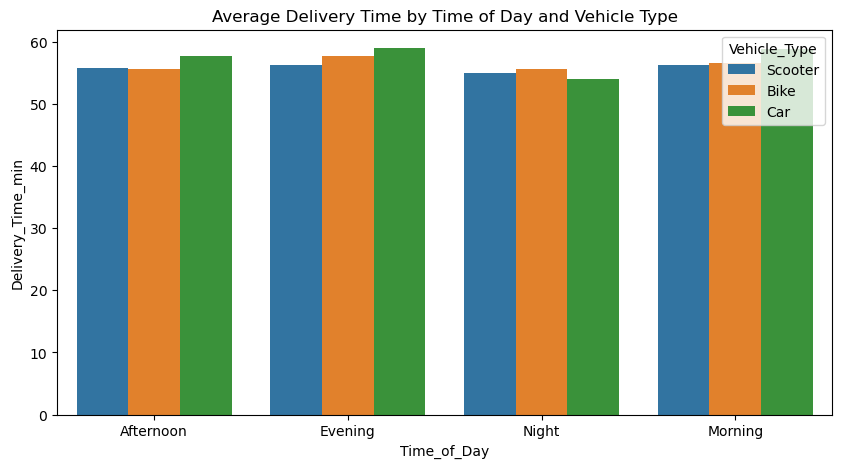

In [33]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x='Time_of_Day',
    y=target,
    hue='Vehicle_Type',
    errorbar=None
)
plt.title('Average Delivery Time by Time of Day and Vehicle Type')
plt.show()


In [34]:
df.describe()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.059970,16.982000,4.579381,56.732000
std,5.696656,7.204553,2.870301,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,4.579381,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


In [35]:
from scipy import stats

print("="*60)
print("STATISTICAL TESTING FOR FEATURE SELECTION")
print("="*60)

# Test 1: Correlation test for numerical features
print("\n1. PEARSON CORRELATION TEST (Numerical Features)")
print("-"*60)
for feature in numerical_features:
    corr_coef, p_value = stats.pearsonr(df[feature], df[target])
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "NS"
    print(f"{feature:25s} | r = {corr_coef:7.4f} | p-value = {p_value:.2e} {significance}")

STATISTICAL TESTING FOR FEATURE SELECTION

1. PEARSON CORRELATION TEST (Numerical Features)
------------------------------------------------------------
Distance_km               | r =  0.7810 | p-value = 2.98e-206 ***
Preparation_Time_min      | r =  0.3073 | p-value = 2.55e-23 ***
Courier_Experience_yrs    | r = -0.0891 | p-value = 4.82e-03 **


In [36]:
# Test 2: ANOVA for categorical features
print("\n2. ANOVA TEST (Categorical Features)")
print("-"*60)
for feature in categorical_features:
    groups = [group[target].values for name, group in df.groupby(feature)]
    f_stat, p_value = stats.f_oneway(*groups)
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "NS"
    print(f"{feature:25s} | F = {f_stat:7.4f} | p-value = {p_value:.2e} {significance}")


2. ANOVA TEST (Categorical Features)
------------------------------------------------------------
Weather                   | F = 10.4991 | p-value = 2.47e-08 ***
Traffic_Level             | F = 19.7513 | p-value = 3.87e-09 ***
Time_of_Day               | F =  0.3468 | p-value = 7.92e-01 NS
Vehicle_Type              | F =  0.5894 | p-value = 5.55e-01 NS


In [37]:




# Test 3: Feature importance ranking
print("\n3. FEATURE IMPORTANCE RANKING (by p-value)")
print("-"*60)
feature_scores = []

for feature in numerical_features:
    corr_coef, p_value = stats.pearsonr(df[feature], df[target])
    feature_scores.append((feature, p_value, abs(corr_coef)))

for feature in categorical_features:
    groups = [group[target].values for name, group in df.groupby(feature)]
    f_stat, p_value = stats.f_oneway(*groups)
    feature_scores.append((feature, p_value, f_stat))

feature_scores_sorted = sorted(feature_scores, key=lambda x: x[1])
for rank, (feature, p_value, score) in enumerate(feature_scores_sorted, 1):
    print(f"{rank}. {feature:25s} | p-value = {p_value:.2e}")

print("\n*** p < 0.001 | ** p < 0.01 | * p < 0.05 | NS = Not Significant")


3. FEATURE IMPORTANCE RANKING (by p-value)
------------------------------------------------------------
1. Distance_km               | p-value = 2.98e-206
2. Preparation_Time_min      | p-value = 2.55e-23
3. Traffic_Level             | p-value = 3.87e-09
4. Weather                   | p-value = 2.47e-08
5. Courier_Experience_yrs    | p-value = 4.82e-03
6. Vehicle_Type              | p-value = 5.55e-01
7. Time_of_Day               | p-value = 7.92e-01

*** p < 0.001 | ** p < 0.01 | * p < 0.05 | NS = Not Significant


In [38]:
df.columns

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [39]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=le.fit_transform(df[col])

In [40]:
df

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,0,0,1,1,13,3.0,54
996,16.28,2,1,2,2,8,9.0,71
997,15.62,3,0,1,2,26,2.0,81
998,14.17,0,1,0,0,8,0.0,55


In [41]:
X=df.drop('Delivery_Time_min',axis=1)
y=df['Delivery_Time_min']

In [42]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
from sklearn.tree import DecisionTreeRegressor
model1=DecisionTreeRegressor()
model1.fit(X_train,y_train)


DecisionTreeRegressor()

In [44]:
y1_pred=model1.predict(X_test)

In [45]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mae=mean_absolute_error(y_test,y1_pred)
mse=mean_squared_error(y_test,y1_pred)
rscore=r2_score(y_test,y1_pred)
print(mae)
print(mse)
print(rscore)

10.25
206.46
0.5393851519088069


In [46]:
y_trainig=model1.predict(X_train)
r2_score(y_trainig,y_train)


1.0

In [47]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(random_state=42)
rf_model.fit(X_train,y_train)


RandomForestRegressor(random_state=42)

In [48]:
y_rfpred=rf_model.predict(X_test)
r2_score(y_test,y_rfpred)

0.7761495490091823

In [49]:
yrf_train=rf_model.predict(X_train)
r2_score(y_train,yrf_train)

0.9542878812849471

In [50]:
from sklearn.model_selection import RandomizedSearchCV
params={
    'n_estimators':np.arange(100,501,50),
    'max_depth':np.arange(3,20),
    'min_samples_split':np.arange(2,20),
    'min_samples_leaf':np.arange(1,10),
    'max_features':['sqrt','log2',1.0]
}
rf=RandomForestRegressor(random_state=42)
random_search=RandomizedSearchCV(
    estimator=rf,
    param_distributions=params,
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'max_depth': array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]),
                                        'max_features': ['sqrt', 'log2', 1.0],
                                        'min_samples_leaf': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                                        'min_samples_split': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19]),
                                        'n_estimators': array([100, 150, 200, 250, 300, 350, 400, 450, 500])},
                   random_state=42, scoring='r2')

In [51]:
best_rf_model=random_search.best_estimator_
best_rf_model.fit(X_train,y_train)

RandomForestRegressor(max_depth=np.int64(16), max_features='sqrt',
                      min_samples_leaf=np.int64(1),
                      min_samples_split=np.int64(4), n_estimators=np.int64(400),
                      random_state=42)

In [52]:
best_y_pred=best_rf_model.predict(X_test)
r2_score(y_test,best_y_pred)

0.7836982589746494

In [53]:
import pandas as pd
import pickle
from sklearn.preprocessing import LabelEncoder

# Load original dataset
df = pd.read_csv("Food_Delivery_Times.csv")

# Dictionary to store all fitted LabelEncoders
label_encoders = {}

# Apply Label Encoding
for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Save LabelEncoders
with open("label_encoders.pkl", "wb") as file:
    pickle.dump(label_encoders, file)

print("label_encoders.pkl created successfully!")
print(label_encoders.keys())

label_encoders.pkl created successfully!
dict_keys(['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'])


In [54]:
import pickle

# Get the best Random Forest model from RandomizedSearchCV
optimized_rf_model = random_search.best_estimator_

# Save the optimized model
with open("optimized_rf_model.pkl", "wb") as file:
    pickle.dump(optimized_rf_model, file)

print("optimized_rf_model.pkl created successfully!")

optimized_rf_model.pkl created successfully!
